<h1>Импорт библиотек

In [13]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [14]:
def sum_prod(X, V):
    result = np.zeros((X[0].shape[0], 1))

    for i in range(len(X)):
        result += np.dot(X[i], V[i])

    return result

def test_sum_prod():
    X = [np.array([[1, 2], [3, 4]]), np.array([[5, 6], [7, 8]])]
    V = [np.array([[1], [2]]), np.array([[3], [4]])]

    result = sum_prod(X, V)
    expected = np.dot(X[0], V[0]) + np.dot(X[1], V[1])
    assert np.allclose(result, expected)
    print("Тест пройден!")

test_sum_prod()

Тест пройден!


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [15]:
def binarize(M, threshold=0.5):
    return (M > threshold).astype(int)

def test_binarize():
    M = np.array([[0.3, 0.6, 0.4], [0.7, 0.2, 0.9]])
    result = binarize(M, 0.5)
    expected = np.array([[0, 1, 0], [1, 0, 1]])
    assert np.array_equal(result, expected)
    print("Тест пройден!")

test_binarize()

Тест пройден!


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [4]:
def unique_rows(mat):

    result = []
    for row in mat:
        result.append(np.unique(row))
    return result

def unique_columns(mat):

    result = []
    for col in mat.T:
        result.append(np.unique(col))
    return result

def test_unique():
    mat = np.array([[1, 2, 2], [3, 3, 3], [1, 1, 2]])

    rows = unique_rows(mat)
    assert np.array_equal(rows[0], [1, 2])
    assert np.array_equal(rows[1], [3])

    cols = unique_columns(mat)
    assert np.array_equal(cols[0], [1, 3])

    print("Тесты пройдены!")

test_unique()

Тесты пройдены!


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

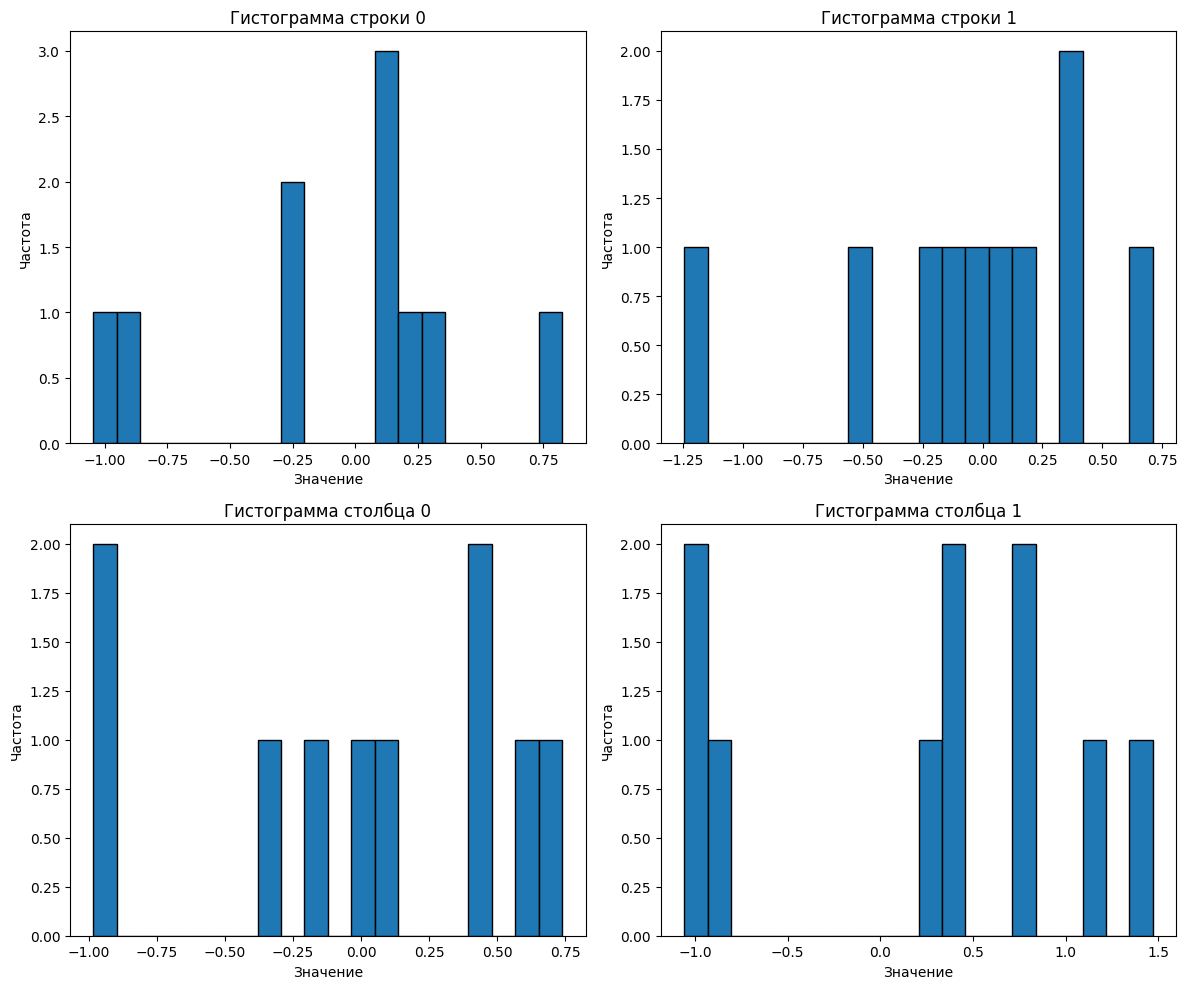

Мат. ожидание для строк: [-0.07904339 -0.04091361  0.0166105  -0.08546967  0.28090467]
Дисперсия для строк: [0.29050376 0.26860372 1.31154012 0.83465082 1.25836033]
Мат. ожидание для столбцов: [-0.01712011  0.22134982 -0.22668513 -0.2821735   0.2140877 ]
Дисперсия для столбцов: [0.33402138 0.75208467 0.87591035 0.59303849 0.84903269]


In [18]:
def create_matrix_with_stats(m, n, mean=0, std=1):

    mat = np.random.normal(mean, std, size=(m, n))

    row_means = np.mean(mat, axis=1)
    row_vars = np.var(mat, axis=1)

    col_means = np.mean(mat, axis=0)
    col_vars = np.var(mat, axis=0)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for i in range(min(2, m)):
        axes[0, i].hist(mat[i, :], bins=20, edgecolor='black')
        axes[0, i].set_title(f'Гистограмма строки {i}')
        axes[0, i].set_xlabel('Значение')
        axes[0, i].set_ylabel('Частота')

    for i in range(min(2, n)):
        axes[1, i].hist(mat[:, i], bins=20, edgecolor='black')
        axes[1, i].set_title(f'Гистограмма столбца {i}')
        axes[1, i].set_xlabel('Значение')
        axes[1, i].set_ylabel('Частота')

    plt.tight_layout()
    plt.show()

    return mat, row_means, row_vars, col_means, col_vars

mat, row_means, row_vars, col_means, col_vars = create_matrix_with_stats(10, 10)
print("Мат. ожидание для строк:", row_means[:5])
print("Дисперсия для строк:", row_vars[:5])
print("Мат. ожидание для столбцов:", col_means[:5])
print("Дисперсия для столбцов:", col_vars[:5])

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [19]:
def chess(m, n, a, b):
    mat = np.zeros((m, n))

    for i in range(m):
        for j in range(n):
            if (i + j) % 2 == 0:
                mat[i, j] = a
            else:
                mat[i, j] = b

    return mat

def test_chess():
    result = chess(3, 3, 1, 0)
    expected = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]])
    assert np.array_equal(result, expected)
    print("Тест пройден!")

test_chess()

Тест пройден!


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

In [20]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):

    image = np.zeros((m, n, 3), dtype=np.uint8)
    image[:] = background_color

    center_x, center_y = n // 2, m // 2

    x1 = max(0, center_x - a // 2)
    x2 = min(n, center_x + a // 2)
    y1 = max(0, center_y - b // 2)
    y2 = min(m, center_y + b // 2)

    image[y1:y2, x1:x2] = rectangle_color

    return image

def draw_ellipse(a, b, m, n, ellipse_color, background_color):

    image = np.zeros((m, n, 3), dtype=np.uint8)
    image[:] = background_color

    center_x, center_y = n // 2, m // 2

    y, x = np.ogrid[:m, :n]

    ellipse = ((x - center_x)**2 / a**2 + (y - center_y)**2 / b**2) <= 1

    image[ellipse] = ellipse_color

    return image

def test_draw_shapes():
    rect = draw_rectangle(50, 30, 100, 100, [255, 0, 0], [0, 0, 0])
    assert rect.shape == (100, 100, 3)

    ellipse = draw_ellipse(40, 20, 100, 100, [0, 255, 0], [0, 0, 0])
    assert ellipse.shape == (100, 100, 3)

    print("Тесты пройдены!")

test_draw_shapes()

Тесты пройдены!


<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [21]:
def analyze_time_series(series, p):

    mean = np.mean(series)


    variance = np.var(series)


    std = np.std(series)


    local_maxima = []
    local_minima = []

    for i in range(1, len(series) - 1):
        if series[i] > series[i-1] and series[i] > series[i+1]:
            local_maxima.append(i)
        if series[i] < series[i-1] and series[i] < series[i+1]:
            local_minima.append(i)


    moving_avg = []
    for i in range(len(series) - p + 1):
        window = series[i:i+p]
        moving_avg.append(np.mean(window))
    moving_avg = np.array(moving_avg)

    return {
        'mean': mean,
        'variance': variance,
        'std': std,
        'local_maxima': np.array(local_maxima),
        'local_minima': np.array(local_minima),
        'moving_average': moving_avg
    }


series = np.array([1, 3, 2, 5, 4, 6, 3, 7, 5, 8, 6, 9, 4])
results = analyze_time_series(series, 3)

print("Математическое ожидание:", results['mean'])
print("Дисперсия:", results['variance'])
print("СКО:", results['std'])
print("Локальные максимумы:", results['local_maxima'])
print("Локальные минимумы:", results['local_minima'])
print("Скользящее среднее:", results['moving_average'])

Математическое ожидание: 4.846153846153846
Дисперсия: 5.053254437869823
СКО: 2.2479444917234552
Локальные максимумы: [ 1  3  5  7  9 11]
Локальные минимумы: [ 2  4  6  8 10]
Скользящее среднее: [2.         3.33333333 3.66666667 5.         4.33333333 5.33333333
 5.         6.66666667 6.33333333 7.66666667 6.33333333]


<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [22]:
def one_hot_encoding(labels):

    labels = np.array(labels)
    n_classes = np.max(labels) + 1
    n_samples = len(labels)

    one_hot = np.zeros((n_samples, n_classes), dtype=int)

    for i, label in enumerate(labels):
        one_hot[i, label] = 1

    return one_hot

def test_one_hot():
    labels = [0, 2, 3, 0]
    result = one_hot_encoding(labels)
    expected = np.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]])
    assert np.array_equal(result, expected)
    print("Тест пройден!")

test_one_hot()

Тест пройден!
